In [804]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
# import plotly_express as px
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import  train_test_split
from sklearn.base import  BaseEstimator ,TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import  StandardScaler
from sklearn.compose import ColumnTransformer   
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report,f1_score,confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import average_precision_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import  roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [805]:
data = pd.read_csv(r"C:\Users\BOSS\Desktop\diabetes.csv")

In [806]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [807]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [808]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [809]:
data["BMI"] = data["BMI"].replace(0, np.nan)
data["BMI"] = data["BMI"].fillna(data["BMI"].median())



In [810]:
# Categorising BMI 
data["BMi_cat"] = pd.cut(
    data["BMI"],
    bins= [0,18.5,25,30,float("inf")],
    labels = ["Underweight","Normal", "Overweight", "Obese"]
)

In [811]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome,BMi_cat
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Normal
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obese
764,2,122,70,27,0,36.8,0.340,27,0,Obese
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obese


In [812]:
data.rename(columns={"Outcome"  :"Status"} ,inplace=True)

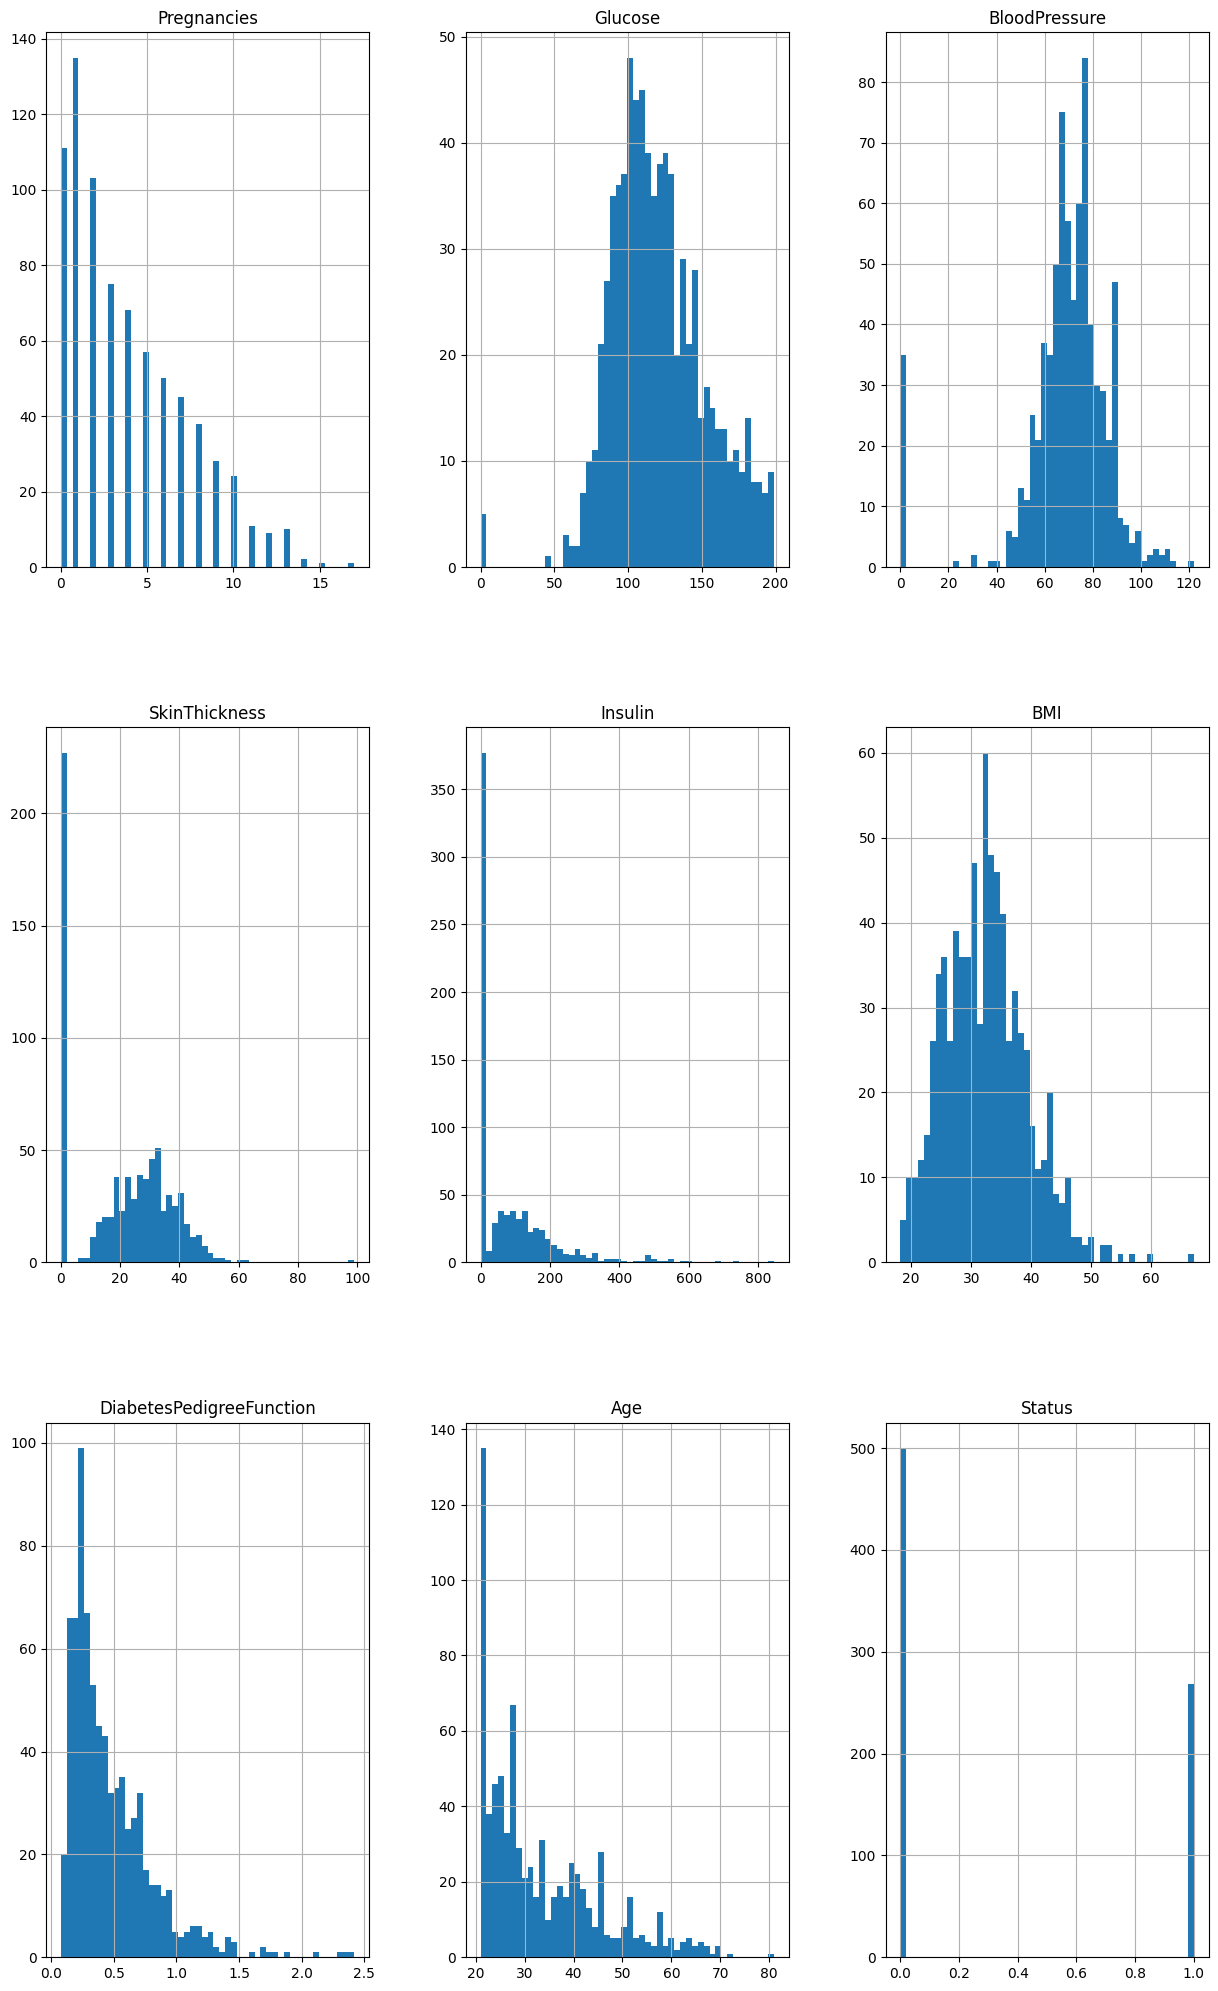

In [813]:
data.hist(bins=50,figsize=(15,25))
plt.show()

In [814]:
bmi_against_dm_status = data.pivot_table(
    index= "Status",
    values= "BMI",
    aggfunc="mean"
).sort_values(by="BMI", ascending=True).head(7)
bmi_against_dm_status

,BMI
Status,
0,30.885600
1,35.383582


In [815]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Status', 'BMi_cat'],
      dtype='object')

<Axes: xlabel='BMI', ylabel='Glucose'>

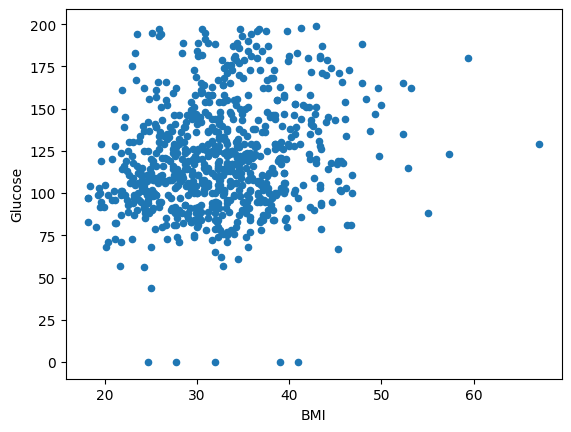

In [816]:
data.plot(kind="scatter", x = "BMI", y ="Glucose")

In [817]:
num_corr = data.corr(numeric_only=True)
outcome_corr = (num_corr["Status"].drop("Status").sort_values(ascending= False))
outcome_corr

Glucose                     0.466581
BMI                         0.312038
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Status, dtype: float64

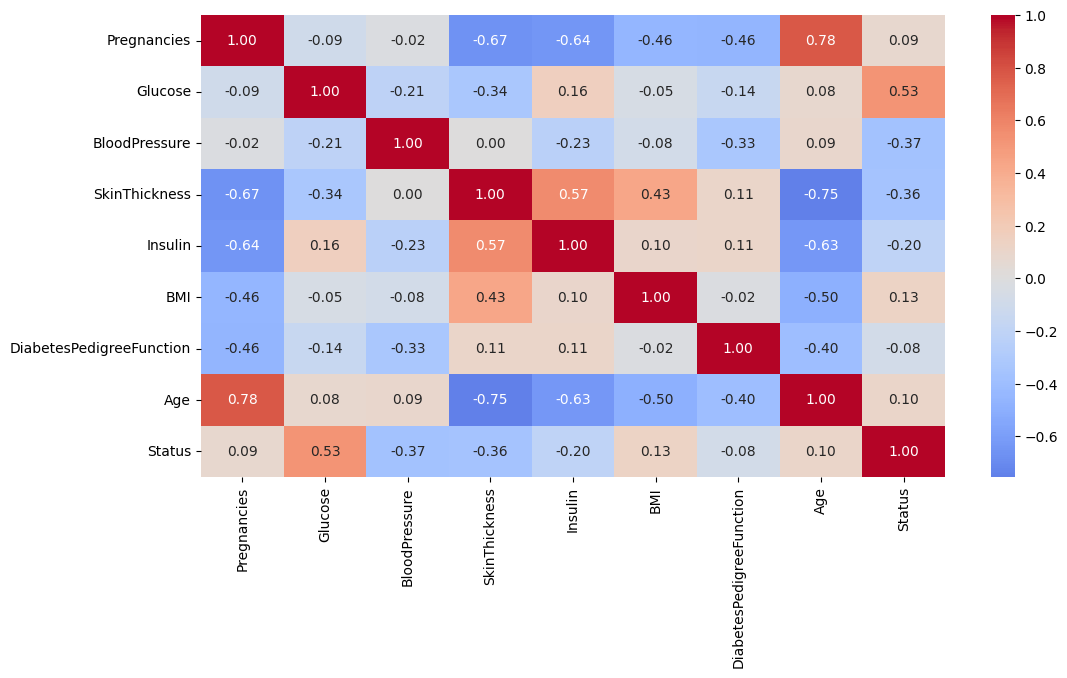

In [818]:
plt.figure(figsize=(12,6))
sns.heatmap(num_corr.corr(),
            cmap= "coolwarm",
            annot= True,
            center = 0,
            fmt= ".2f")
plt.show()

In [819]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Status', 'BMi_cat'],
      dtype='object')

In [820]:
train_set,test_set = train_test_split(data,train_size=0.2,random_state= 42)

In [821]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Status,BMi_cat
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Normal
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obese
764,2,122,70,27,0,36.8,0.340,27,0,Obese
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obese


In [822]:
x = data.drop("Status", axis = 1)
y= data["Status"]

In [823]:
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state= 42)

for train_index, test_index in split.split(data,data["Status"]):
    strat_train_set = data.iloc[train_index]
    strat_test_set = data.iloc[test_index]
    

In [824]:
# cols_to_drop = ["Status"]
# strat_train_set = strat_train_set.drop(columns=cols_to_drop, errors="ignore")
# strat_test_set = strat_test_set.drop(columns=cols_to_drop,errors="ignore")

How Can We Train a Model Without First Exploring The Training Set? 
Now Lets do Some EDA

In [825]:
Dm = strat_train_set.copy()

In [826]:
Dm.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Status', 'BMi_cat'],
      dtype='object')

In [827]:
Dm_num= Dm.corr(numeric_only = True)
Dm_num_corr = (Dm_num["Status"].drop("Status").sort_values(ascending = False))

Dm_num_corr

Glucose                     0.479330
BMI                         0.328830
Age                         0.240676
Pregnancies                 0.208173
DiabetesPedigreeFunction    0.165312
Insulin                     0.164197
SkinThickness               0.093789
BloodPressure               0.082383
Name: Status, dtype: float64

<Axes: >

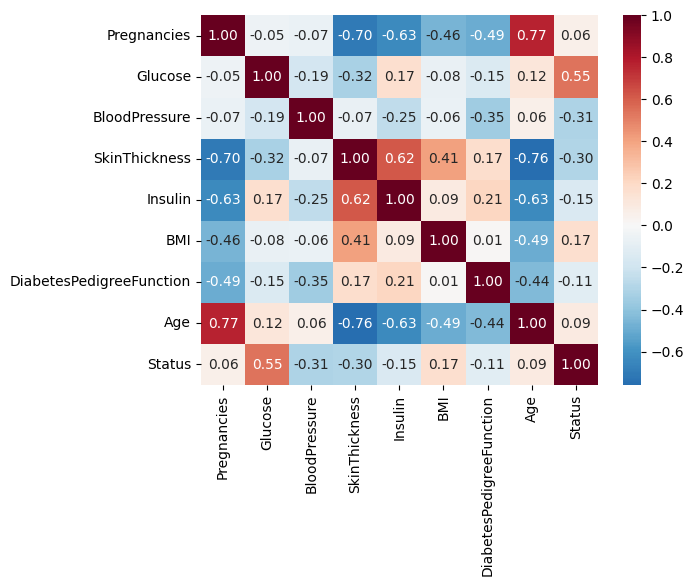

In [828]:
plt.Figure(figsize=(12,6))
sns.heatmap(Dm_num.corr(),
            cmap= "RdBu_r",
            fmt = ".2f",
            annot= True,
            center = 0
            )

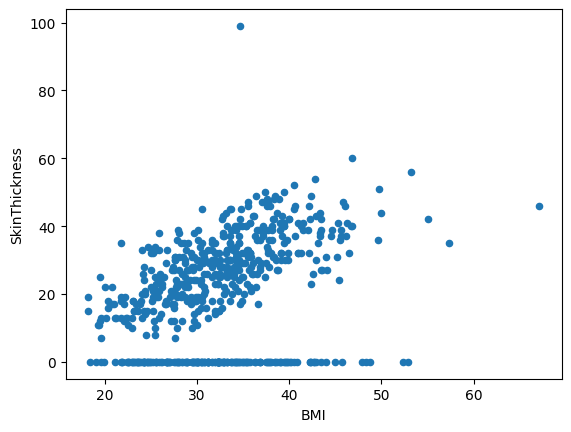

In [829]:
Dm.plot(kind = "scatter", y = "SkinThickness", x = "BMI")
plt.show("Glucose level against Skinthickness")

<Axes: xlabel='BMI', ylabel='Glucose'>

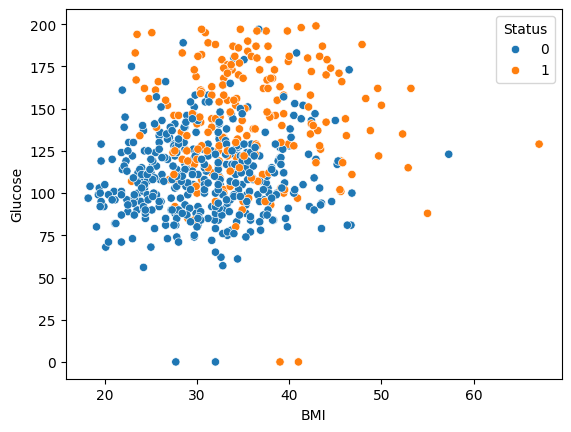

In [830]:
sns.scatterplot (data=Dm, x = "BMI", y = "Glucose", hue="Status")

<Axes: xlabel='Glucose', ylabel='Insulin'>

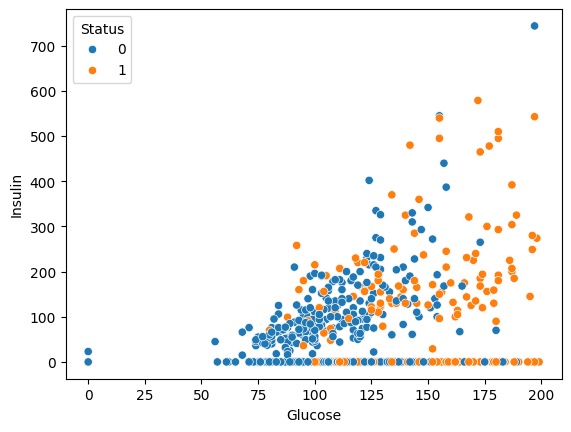

In [831]:
sns.scatterplot(data= Dm, x = "Glucose", y = "Insulin", hue= "Status")

In [832]:
cross_T= pd.crosstab(Dm["BMi_cat"],Dm["Status"], normalize = "index")*100
cross_T

Status,0,1
BMi_cat,,
Underweight,100.000000,0.000000
Normal,91.860465,8.139535
Overweight,76.760563,23.239437
Obese,54.569191,45.430809


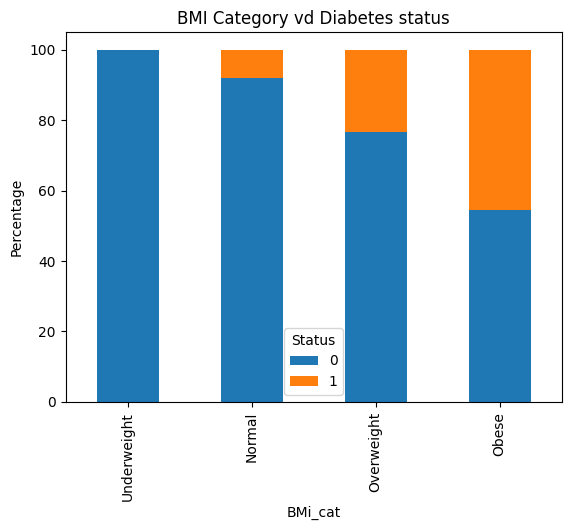

In [833]:
cross_T.plot(kind= "bar", stacked = "True")
plt.ylabel("Percentage")
plt.title("BMI Category vd Diabetes status")
plt.show()

In [834]:
dm_num_val = Dm.select_dtypes(include=[np.number])

Splitting training set and test set into x,y 

In [835]:
x_train = strat_train_set.drop("Status", axis=1)
y_train = strat_train_set["Status"]

x_test = strat_test_set.drop("Status", axis=1)
y_test = strat_test_set["Status"]

In [836]:
from sklearn.base import BaseEstimator, TransformerMixin

In [837]:
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Status,BMi_cat
0,6,148,72,35,0,33.6,0.627,50,1,Obese
1,1,85,66,29,0,26.6,0.351,31,0,Overweight
2,8,183,64,0,0,23.3,0.672,32,1,Normal
3,1,89,66,23,94,28.1,0.167,21,0,Overweight
4,0,137,40,35,168,43.1,2.288,33,1,Obese
...,...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0,Obese
764,2,122,70,27,0,36.8,0.340,27,0,Obese
765,5,121,72,23,112,26.2,0.245,30,0,Overweight
766,1,126,60,0,0,30.1,0.349,47,1,Obese


In [838]:
class DiabetesFeaturesAdder(BaseEstimator,TransformerMixin):
    def __init__(self,add_risk_features=True, add_ratios= True, add_bins= True, add_polynomial = True):
        self.add_risk_features = add_risk_features
        self.add_ratios = add_ratios
        self.add_bins = add_bins
        self.add_polynomial = add_polynomial
    
    def fit(self,x,y=None):
        return self
    
    def transform(self, x,y=None):
        x = x.copy()
        x = x.replace([np.inf, -np.inf], np.nan)
        
        if self.add_risk_features:
            x["glucose_insulin"] =((x["Glucose"]/18) * x["Insulin"])/22.5
            x["glucose_bmi"] = x["Glucose"]* x["BMI"]
            x["insulin_bmi"] = x["Insulin"] * x["BMI"]
         
         
        if self.add_ratios:
            x["glucose_to_bmi"] = x["Glucose"] / x["BMI"].replace(0, np.nan)
            x["Glucose_to_insulin"] =x["Glucose"]  / x["Insulin"].replace(0, np.nan)
            
        if self.add_polynomial:
            x["glucose_squared"] = x["Glucose"]**2
            x["BMI_squared"] = x["BMI"]**2 
            x["Insulin_squared"] = x["Insulin"]**2
            x["Insulin_log"] = np.log1p(x["Insulin"])
            x["Glucose_log"] = np.log1p(x["Glucose"])  
        return x  
        
        

In [839]:
attr_addr = DiabetesFeaturesAdder(add_polynomial=True)
diabetes_extra_attributes = attr_addr.fit_transform(dm_num_val)

In [840]:
num_pipeline = Pipeline([
    ("attr_addr", DiabetesFeaturesAdder()),
    ("imputer", SimpleImputer(strategy="median")),
    ("std_scale", StandardScaler())
    
    
])

In [841]:
x_train_num = x_train.select_dtypes(include=[np.number])

In [842]:
x_train.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'BMi_cat'],
      dtype='object')

In [843]:
num_attributes = x_train.select_dtypes(include=[np.number]).columns.tolist()
cat_attributes = ["BMi_cat"]



In [844]:
full_pipeline= ColumnTransformer([
    ("num",num_pipeline,num_attributes),
    ("cat",OneHotEncoder(handle_unknown="ignore"),cat_attributes) 
])

Diabetes_mellitus = full_pipeline.fit_transform(x_train)

In [845]:
# x_test_transformed = full_pipeline.transform(x_test)

In [846]:
SGD_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", SGDClassifier(class_weight= "balanced", random_state=42))
])

In [847]:
SDG_model = SGD_pipeline.fit(x_train,y_train)
SDG_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pregnancies','Glucose','BloodPressure',...,'DiabetesPedigreeFunction', 'Age','BMi_cat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [848]:
y_test_pred = SDG_model.predict(x_test)

In [849]:
print(classification_report(y_test_pred,y_test))

              precision    recall  f1-score   support

           0       0.63      0.82      0.71        77
           1       0.74      0.52      0.61        77

    accuracy                           0.67       154
   macro avg       0.69      0.67      0.66       154
weighted avg       0.69      0.67      0.66       154



In [850]:
print(y_test.value_counts(normalize=True))

Status
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [851]:
print(y_train.value_counts())

Status
0    400
1    214
Name: count, dtype: int64


In [852]:
x_train.isna().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
BMi_cat                     0
dtype: int64

In [853]:
y_scores = SDG_model.decision_function(x_test)

threshold = np.arange(-2,2,0.1)

for t in threshold:
     y_pred = (y_scores >= t).astype(int)
     print(t,f1_score(y_test,y_pred))

-2.0 0.6530612244897959
-1.9 0.6575342465753424
-1.7999999999999998 0.6620689655172414
-1.6999999999999997 0.6527777777777778
-1.5999999999999996 0.6433566433566433
-1.4999999999999996 0.647887323943662
-1.3999999999999995 0.6382978723404256
-1.2999999999999994 0.6428571428571429
-1.1999999999999993 0.6330935251798561
-1.0999999999999992 0.6277372262773723
-0.9999999999999991 0.6277372262773723
-0.899999999999999 0.6268656716417911
-0.7999999999999989 0.6165413533834586
-0.6999999999999988 0.6165413533834586
-0.5999999999999988 0.6165413533834586
-0.49999999999999867 0.6165413533834586
-0.3999999999999986 0.6165413533834586
-0.2999999999999985 0.6060606060606061
-0.1999999999999984 0.6106870229007634
-0.09999999999999831 0.6106870229007634
1.7763568394002505e-15 0.6106870229007634
0.10000000000000187 0.6106870229007634
0.20000000000000195 0.6106870229007634
0.30000000000000204 0.6153846153846154
0.40000000000000213 0.6153846153846154
0.5000000000000022 0.6153846153846154
0.600000000000

lets compare -1.8 and 1.8 thresholds and see how they would perform against the recall 

In [854]:
for n  in [-1.8,0,1.8]:
    y_pred = (y_scores >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))


Threshold = 1.9000000000000035
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       100
           1       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


Threshold = 1.9000000000000035
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       100
           1       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154


Threshold = 1.9000000000000035
              precision    recall  f1-score   support

           0       0.83      0.77      0.80       100
           1       0.62      0.70      0.66        54

    accuracy                           0.75       154
   macro avg       0.73      0.7

looking at the thresholds, 1.9 performs best with improved recall and precision.

lets plot this in ROC-AUC

In [855]:
precisions, recalls,thresholds = precision_recall_curve(y_test,y_scores)

def plot_precision_recall_curve_vs_threshold(precisions,recall, threshold):
    plt.plot(threshold, precisions[:-1], "b--", label ="Precision")
    plt.plot(threshold,recall[:-1], "g-", label="recall")
    plot_precision_recall_curve_vs_threshold(precisions,recall,threshold)

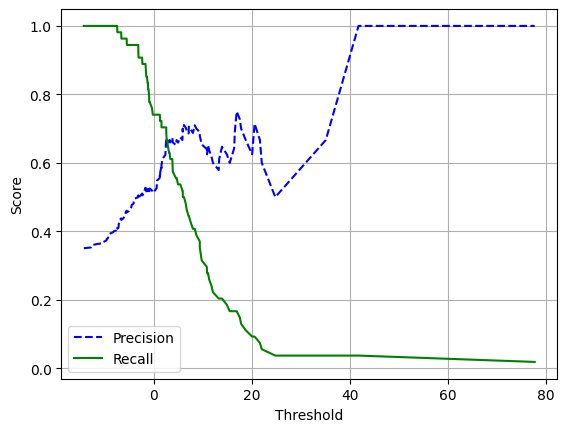

In [856]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

from the graph, seems a threshold of 2.0-2.5 might give us an improved recall and precision, lets try and see.

In [857]:
SDG_scores = SDG_model.decision_function(x_test)

threshold = np.arange(-2,2.5,0.1)

for t in threshold:
     y_pred = (SDG_scores >= t).astype(int)
     print(t,f1_score(y_test,y_pred))

-2.0 0.6530612244897959
-1.9 0.6575342465753424
-1.7999999999999998 0.6620689655172414
-1.6999999999999997 0.6527777777777778
-1.5999999999999996 0.6433566433566433
-1.4999999999999996 0.647887323943662
-1.3999999999999995 0.6382978723404256
-1.2999999999999994 0.6428571428571429
-1.1999999999999993 0.6330935251798561
-1.0999999999999992 0.6277372262773723
-0.9999999999999991 0.6277372262773723
-0.899999999999999 0.6268656716417911
-0.7999999999999989 0.6165413533834586
-0.6999999999999988 0.6165413533834586
-0.5999999999999988 0.6165413533834586
-0.49999999999999867 0.6165413533834586
-0.3999999999999986 0.6165413533834586
-0.2999999999999985 0.6060606060606061
-0.1999999999999984 0.6106870229007634
-0.09999999999999831 0.6106870229007634
1.7763568394002505e-15 0.6106870229007634
0.10000000000000187 0.6106870229007634
0.20000000000000195 0.6106870229007634
0.30000000000000204 0.6153846153846154
0.40000000000000213 0.6153846153846154
0.5000000000000022 0.6153846153846154
0.600000000000

In [858]:
for n  in [-1.8,0,2.5]:
    y_pred = (SDG_scores >= t).astype(int)
    print(f"\nThreshold = {t}")
    print(classification_report(y_test, y_pred))


Threshold = 2.400000000000004
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154


Threshold = 2.400000000000004
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75      0.74       154
weighted avg       0.77      0.76      0.76       154


Threshold = 2.400000000000004
              precision    recall  f1-score   support

           0       0.83      0.79      0.81       100
           1       0.64      0.70      0.67        54

    accuracy                           0.76       154
   macro avg       0.74      0.75  

the output from this new threshold shows The default decision threshold of the SGD classifier was tuned using the Precision-Recall tradeoff. A threshold of 2.4 produced the best balance of performance, increasing accuracy from 67% to 76% and improving the F1-score for diabetes prediction from 0.61 to 0.67 while maintaining a recall of 70%.

In [859]:
precisions, recalls,thresholds = precision_recall_curve(y_test,y_scores)

def plot_precision_recall_curve_vs_threshold(precisions,recall, threshold):
    plt.plot(threshold, precisions[:-1], "b--", label ="Precision")
    plt.plot(threshold,recall[:-1], "g-", label="recall")
    plot_precision_recall_curve_vs_threshold(precisions,recall,threshold)

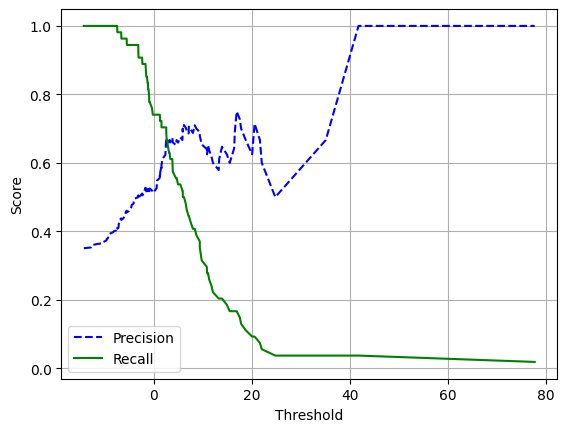

In [860]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()

plt.show()

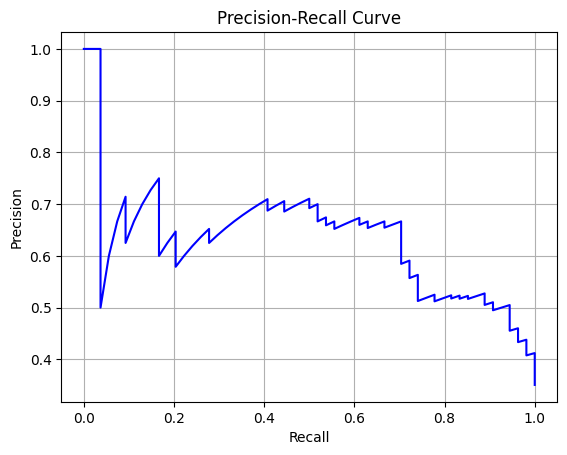

In [861]:
precisions, recall,threshold = precision_recall_curve(y_test,SDG_scores)
plt.plot(recall, precisions, "b-")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()

plt.show()

The model has predictive power, but there is still overlap between diabetic and non-diabetic patients.

In [862]:
pr_auc = average_precision_score(y_test, y_scores)
print("PR-AUC:", pr_auc)

PR-AUC: 0.6366106730475767


In [863]:
roc_auc = roc_auc_score(y_test, SDG_scores)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7974074074074073


<!-- # ROC curve plots the true positive rate (another name
# for recall) against the false positive rate. The FPR is the ratio of negative instances that
# are incorrectly classified as positive. It is equal to one minus the true negative rate, 
# which is the ratio of negative instances that are correctly classified as negative. The
# TNR is also called specificity. Hence the ROC curve plots sensitivity (recall) versus
# 1 – specificity. -->


In [864]:
fpr, tpr,threshold= roc_curve(y_test, SDG_scores)

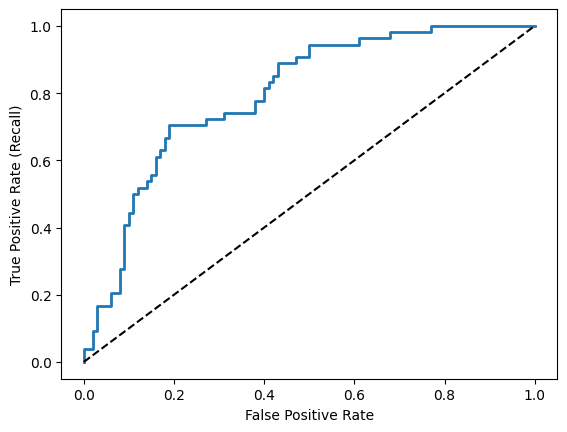

In [865]:
def plot_roc_curve(fpr,tpr,label=None):
    plt.plot(fpr,tpr,linewidth= 2,label=label)
    plt.plot([0,1],[0,1], "k--")
    
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")    
plot_roc_curve(fpr,tpr)
plt.show()

In [866]:

rand_f_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", RandomForestClassifier(
    n_estimators=200,
    max_depth= None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=1
))
])

random_model =rand_f_pipeline.fit(x_train,y_train)
random_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pregnancies','Glucose','BloodPressure',...,'DiabetesPedigreeFunction', 'Age','BMi_cat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [867]:
rand_y_test_pred = random_model.predict(x_test)

In [868]:
print("Random Forest Classification Report")
print(classification_report(y_test, rand_y_test_pred))

Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.77      0.82      0.80       100
           1       0.62      0.56      0.59        54

    accuracy                           0.73       154
   macro avg       0.70      0.69      0.69       154
weighted avg       0.72      0.73      0.72       154



In [869]:
rand_prob = random_model.predict_proba(x_test)

In [870]:
forest_scores = rand_prob[:,1]


In [871]:
# thresholds = np.arange(0.1, 1.0, 0.05)

# for t in thresholds:
#     rand_y_pred = (forest_scores >= t).astype(int)
#     print(t, f1_score(y_test, rand_y_pred))

In [872]:
# since random forest uses probabilities instead of decision function as in sdg, 
# we use a range of 0-1  since probabilty outcome is either 0 or 1

In [873]:
thresholds = np.arange(0.1,1.0,0.05)


for t in thresholds:
    rand_y_pred = (forest_scores >= t).astype(int)
    print(t, f1_score(y_test, rand_y_pred))

0.1 0.6097560975609756
0.15000000000000002 0.6535947712418301
0.20000000000000004 0.6896551724137931
0.25000000000000006 0.7007299270072993
0.30000000000000004 0.706766917293233
0.3500000000000001 0.6829268292682927
0.40000000000000013 0.6551724137931034
0.45000000000000007 0.5849056603773585
0.5000000000000001 0.5882352941176471
0.5500000000000002 0.5473684210526316
0.6000000000000002 0.5116279069767442
0.6500000000000001 0.475
0.7000000000000002 0.40540540540540543
0.7500000000000002 0.37681159420289856
0.8000000000000002 0.3283582089552239
0.8500000000000002 0.28125
0.9000000000000002 0.22580645161290322
0.9500000000000003 0.10526315789473684


In [874]:
for t in np.arange(0.3, 1.0, 0.05):
    y_pred = (forest_scores >= t).astype(int)

    print(f"\nThreshold = {t:.2f}")
    print(classification_report(y_test, y_pred))


Threshold = 0.30
              precision    recall  f1-score   support

           0       0.91      0.68      0.78       100
           1       0.59      0.87      0.71        54

    accuracy                           0.75       154
   macro avg       0.75      0.78      0.74       154
weighted avg       0.80      0.75      0.75       154


Threshold = 0.35
              precision    recall  f1-score   support

           0       0.86      0.73      0.79       100
           1       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154


Threshold = 0.40
              precision    recall  f1-score   support

           0       0.83      0.76      0.79       100
           1       0.61      0.70      0.66        54

    accuracy                           0.74       154
   macro avg       0.72      0.73      0.72       154
weighted avg       0

In [875]:
# Lower threshold → more diabetes cases detected
# Higher threshold → fewer detections, more misses

In [876]:
# ❗ Missing a diabetic patient (false negative)
# → dangerous

# ❗ False alarm (false positive)
# → less dangerous (just further testing)

In [877]:
precisions, recalls,thresholds = precision_recall_curve(y_test,forest_scores)

def plot_precision_recall_curve_vs_threshold(precisions,recall, threshold):
    plt.plot(threshold, precisions[:-1], "b--", label ="Precision")
    plt.plot(threshold,recall[:-1], "g-", label="recall")
    plot_precision_recall_curve_vs_threshold(precisions,recall,threshold)

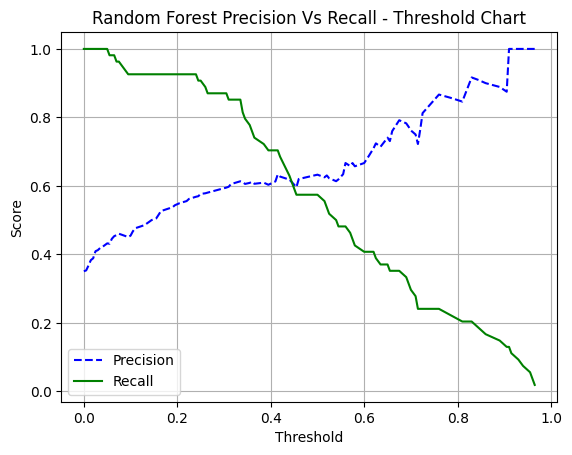

In [878]:
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.title("Random Forest Precision Vs Recall - Threshold Chart")

plt.show()

In [879]:
forest_fpr,forest_tpr,forest_threshold =roc_curve(y_test,forest_scores) 

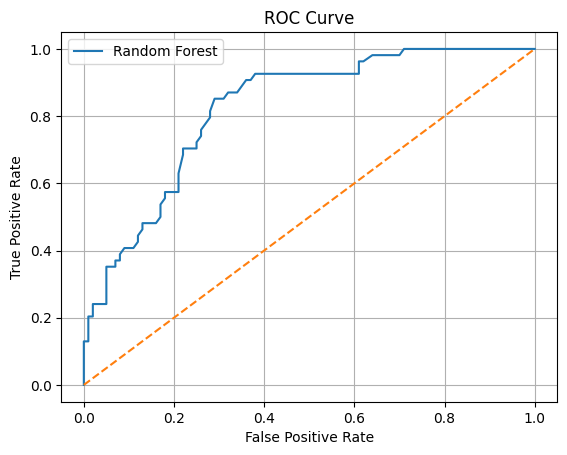

In [880]:
plt.plot(forest_fpr, forest_tpr, label="Random Forest")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

In [881]:
# plt.plot(fpr,tpr,"b:", label= "SGD")
# plot_roc_curve(forest_fpr,forest_tpr,"Random Forest")
# plt.legend(loc="lower right")
# plt.xlabel("False Positive Rate")
# plt.ylabel("True Positive Rate")


# plt.grid()
# plt.show()

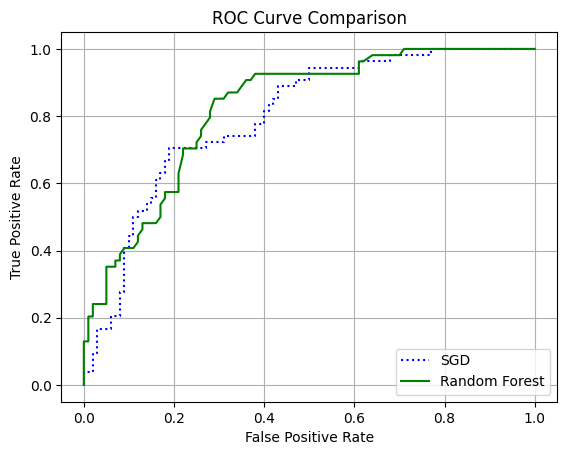

In [882]:
plt.plot(fpr, tpr, "b:", label="SGD")
plt.plot(forest_fpr, forest_tpr, "g-", label="Random Forest")

plt.legend(loc="lower right")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.grid()
plt.show()

Gradient BOOSt

In [883]:
G_boost = GradientBoostingClassifier(random_state=42)

In [884]:
G_boost_pipeline = Pipeline([
    ("preprocessing", full_pipeline),
    ("model", GradientBoostingClassifier(random_state=42))
])

In [885]:
G_boos_model = G_boost_pipeline.fit(x_train, y_train)
G_boos_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Pregnancies','Glucose','BloodPressure',...,'DiabetesPedigreeFunction', 'Age','BMi_cat']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pas

In [886]:
G_boost_y_pred = G_boos_model.predict(x_test)

In [887]:
print("Gradient Boosting Classification Report")
print(classification_report(y_test, G_boost_y_pred))

Gradient Boosting Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.80       100
           1       0.64      0.59      0.62        54

    accuracy                           0.74       154
   macro avg       0.71      0.71      0.71       154
weighted avg       0.74      0.74      0.74       154



In [888]:
G_proba= G_boos_model.predict_proba(x_test)

g_scores = G_proba[:,1]

In [889]:
thresholds = np.arange(0.1,1.0,0.05)


for t in thresholds:
    G_y_pred = (g_scores>= t).astype(int)
    print(t, f1_score(y_test, G_y_pred))

0.1 0.6754966887417219
0.15000000000000002 0.704225352112676
0.20000000000000004 0.7101449275362319
0.25000000000000006 0.696969696969697
0.30000000000000004 0.6610169491525424
0.3500000000000001 0.6428571428571429
0.40000000000000013 0.6363636363636364
0.45000000000000007 0.6422018348623854
0.5000000000000001 0.6153846153846154
0.5500000000000002 0.5684210526315789
0.6000000000000002 0.5591397849462365
0.6500000000000001 0.5454545454545454
0.7000000000000002 0.5060240963855421
0.7500000000000002 0.45569620253164556
0.8000000000000002 0.4155844155844156
0.8500000000000002 0.34782608695652173
0.9000000000000002 0.28125
0.9500000000000003 0.07142857142857142


In [890]:
# from the threshold output, "0.2" had the best value of prediction, 
# so lets try and generate the classification report per that threshold and see how best the model 
# would perform

In [891]:
for t in np.arange(0.2, 1.0, 0.05):
    y_pred = (forest_scores >= t).astype(int)

    print(f"\nThreshold = {t:.2f}")
    print("Gradient Boost report\n",classification_report(y_test, y_pred))


Threshold = 0.20
Gradient Boost report
               precision    recall  f1-score   support

           0       0.94      0.59      0.72       100
           1       0.55      0.93      0.69        54

    accuracy                           0.71       154
   macro avg       0.74      0.76      0.71       154
weighted avg       0.80      0.71      0.71       154


Threshold = 0.25
Gradient Boost report
               precision    recall  f1-score   support

           0       0.93      0.64      0.76       100
           1       0.58      0.91      0.71        54

    accuracy                           0.73       154
   macro avg       0.75      0.77      0.73       154
weighted avg       0.80      0.73      0.74       154


Threshold = 0.30
Gradient Boost report
               precision    recall  f1-score   support

           0       0.91      0.68      0.78       100
           1       0.59      0.87      0.71        54

    accuracy                           0.75       154
   ma

In [892]:
# 0.2 threshold made  Gradient Boost model catch almost ALL diabetics, but with more false positives.
# 0.25 threshold made Gradieent Boost have  Balanced detection with strong recall and improved precision

In [893]:
precisions, recalls,thresholds = precision_recall_curve(y_test,g_scores)

def plot_precision_recall_curve_vs_threshold(precisions,recall, threshold):
    plt.plot(threshold, precisions[:-1], "b--", label ="Precision")
    plt.plot(threshold,recall[:-1], "g-", label="recall")
    plot_precision_recall_curve_vs_threshold(precisions,recall,threshold)

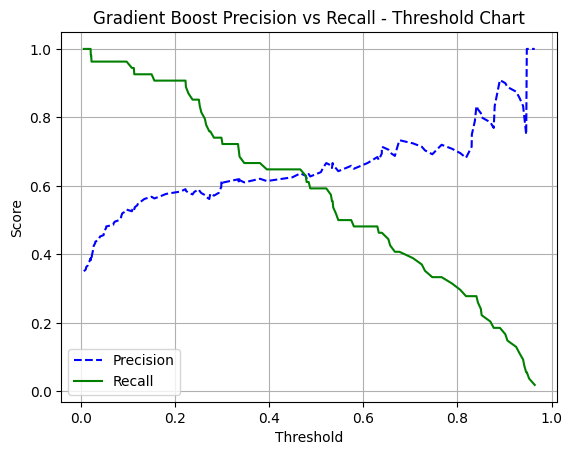

In [894]:

precisions, recalls, thresholds = precision_recall_curve(y_test, g_scores)

plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.title("Gradient Boost Precision vs Recall - Threshold Chart")

plt.show()

In [895]:
boost_fpr,boost_tpr,boost_threshold =roc_curve(y_test,g_scores) 

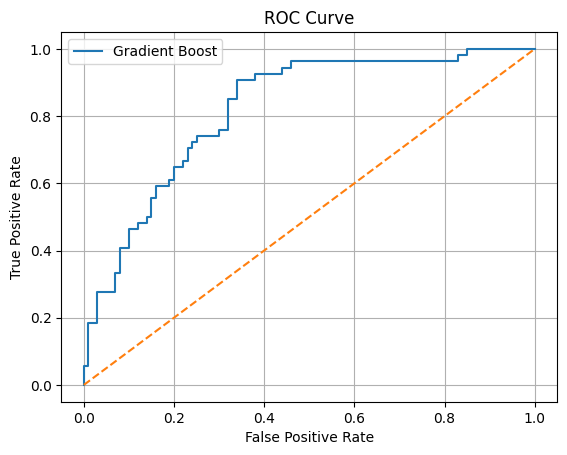

In [896]:
plt.plot(boost_fpr, boost_tpr, label="Gradient Boost")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid()
plt.show()

Now lets compare all models and plot them on a single graph to show their performances

In [897]:
def evaluate_model(y_test, y_scores, threshold):
    y_pred = (y_scores >= threshold).astype(int)

    return {
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_scores),
        "PR-AUC": average_precision_score(y_test, y_scores)
    }

In [898]:
rf_proba = random_model.predict_proba(x_test)[:, 1]
gb_proba = G_boos_model.predict_proba(x_test)[:, 1]

In [899]:
sgd_results = evaluate_model(y_test, SDG_scores, threshold=2.4)   # your best SGD threshold
rf_results  = evaluate_model(y_test, rf_proba, threshold=0.30)
gb_results  = evaluate_model(y_test, gb_proba, threshold=0.25)

In [900]:
results_df = pd.DataFrame({
    "SGD": sgd_results,
    "Random Forest": rf_results,
    "Gradient Boosting": gb_results
}).T

print(results_df)

                   Precision    Recall  F1-score   ROC-AUC    PR-AUC
SGD                 0.644068  0.703704  0.672566  0.797407  0.636611
Random Forest       0.594937  0.870370  0.706767  0.822963  0.708277
Gradient Boosting   0.589744  0.851852  0.696970  0.820000  0.694771


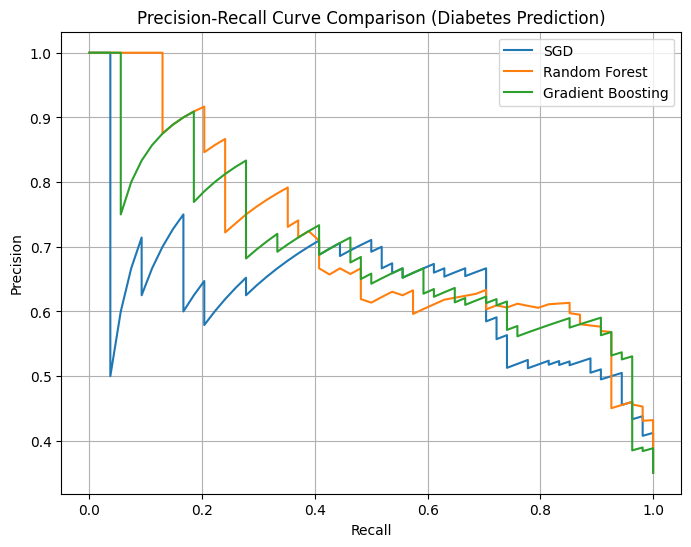

In [901]:
# SGD (scores)
prec_sgd, rec_sgd, _ = precision_recall_curve(y_test, SDG_scores)

# Random Forest
prec_rf, rec_rf, _ = precision_recall_curve(y_test, rf_proba)

# Gradient Boosting
prec_gb, rec_gb, _ = precision_recall_curve(y_test, gb_proba)

plt.figure(figsize=(8,6))

plt.plot(rec_sgd, prec_sgd, label="SGD")
plt.plot(rec_rf, prec_rf, label="Random Forest")
plt.plot(rec_gb, prec_gb, label="Gradient Boosting")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison (Diabetes Prediction)")
plt.legend()
plt.grid()
plt.show()